<a href="https://colab.research.google.com/github/alatasyusuf521-commits/ZaturreTespitProjesi/blob/main/ZaturreTespitProjesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

base_dir = '/content/drive/MyDrive/chest_xray'

train_dir = os.path.join(base_dir, 'train')#os.path.join --> iki farklı yolu akıllıca birleştirmeye yarıyor base_dir ve train_dir klasörünü birleştirerek eğitim klasörümüzün tam adını oluşturuyor.
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')#chest_xray klasöründeki PNEUMONIA dosyasına ulaşır.
train_normal_dir = os.path.join(train_dir, 'NORMAL')#chest_xray klasöründeki NORMAL dosyasına ulaşır.

In [3]:
num_pneumonia_train = len(os.listdir(train_pneumonia_dir))#Hastalıklı görüntülerin sayısını alıyoruz.
num_normal_train = len(os.listdir(train_normal_dir))#Normal görüntülerin sayısını alıyoruz.

print(f"Eğitim setindeki ZATÜRRELİ görüntü sayısı: {num_pneumonia_train}")
print(f"Eğitim setindeki NORMAL görüntü sayısı: {num_normal_train}")
print("-" * 30)

num_pneumonia_test = len(os.listdir(os.path.join(test_dir,'PNEUMONIA')))
num_normal_test = len(os.listdir(os.path.join(test_dir,'NORMAL')))

print(f"Test setindeki ZATÜRRELİ görüntü sayısı: {num_pneumonia_test}")
print(f"Test setindeki NORMAL görüntü sayısı: {num_normal_test}")

Eğitim setindeki ZATÜRRELİ görüntü sayısı: 3875
Eğitim setindeki NORMAL görüntü sayısı: 1341
------------------------------
Test setindeki ZATÜRRELİ görüntü sayısı: 390
Test setindeki NORMAL görüntü sayısı: 234


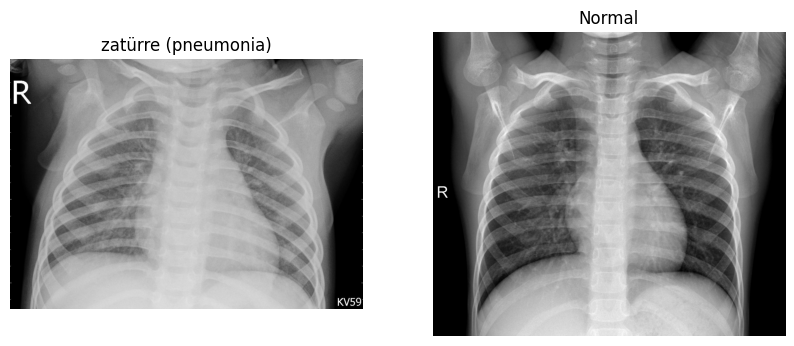

In [4]:
def show_sample_images(PNEUMONIA_dir, NORMAL_dir):
    pneumonia_img_name = os.listdir(PNEUMONIA_dir)[0]
    pneumonia_img_path = os.path.join(PNEUMONIA_dir, pneumonia_img_name)
    pneumonia_img = cv2.imread(pneumonia_img_path)

    normal_img_name = os.listdir(NORMAL_dir)[0]
    normal_img_path = os.path.join(NORMAL_dir, normal_img_name)
    normal_img = cv2.imread(normal_img_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)#tuval 1 satır ve 2 sütundan oluşacak soldaki resme göre pozisyon alacak.
    plt.title('zatürre (pneumonia)')
    plt.imshow(pneumonia_img)
    plt.axis('off')#eksen çizgilerini, sayılarını ve çentikleri gizlemeye çalışır

    plt.subplot(1, 2, 2)#sağdaki resme göre pozisyon alacak.
    plt.title('Normal')
    plt.imshow(normal_img)
    plt.axis('off')

    plt.show()

show_sample_images(train_pneumonia_dir, train_normal_dir)#iki farklı klasörden rastgele örnek resimler seçip ekranda yan yana gösterir.

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Ensure os is imported, though it is already in cell ikKHZnR371A0

train_datagen = ImageDataGenerator(
    rescale=1./255,#255 e bölerek 0 ve 1 arasına sıkıştıracak.
    rotation_range=20,#görüntüleri -20 ve +20 derece arasında döndürüyor.
    width_shift_range=0.1,#görüntüleri yatayda toplam genişliğin %10 u kadar rastgele sağa ya da sola kaydırıyor.
    height_shift_range=0.1,#görüntüleri dikeyde toplam yüksekliğin %10 u kadar rastgele yukarı ya da aşağı kaydırıyor.
    shear_range=0.1,#%10 luk bir açı ile eğiyor.
    zoom_range=0.1,#görüntüyü %10 oranında rastgele yakınlaştırma ya da uzaklaştırma uyguluyor.
    horizontal_flip=True,#görüntüleri yatay eksende rastgele olarak ayna görüntüsü gibi çeviriyor.
    fill_mode='nearest'#döndürme ya da kaydırma gibi işlemler sonucu oluşan boş pikselleri ona en yakın piksellerle dolduruyor.
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32#modele her adımda kaçar tane görüntü göndereceğimizi belirtiyoruz resimleri 32 li gruplar halinde göndereceğiz.
IMG_HEIGHT = 180#180 yüksekliği olacak
IMG_WIDTH = 180#180 genişliği olacak

# Add checks for directory existence
if not os.path.exists(train_dir):
    print(f"Hata: Eğitim dizini bulunamadı: {train_dir}")
    print("Lütfen Google Drive'ınızın bağlı olduğundan ve 'chest_xray/train' klasörünün doğru konumda olduğundan emin olun.")
    # Optionally, you might want to exit or raise an exception here to stop execution early

if not os.path.exists(val_dir):
    print(f"Hata: Validasyon dizini bulunamadı: {val_dir}")
    print("Lütfen Google Drive'ınızın bağlı olduğundan ve 'chest_xray/val' klasörünün doğru konumda olduğundan emin olun.")

if not os.path.exists(test_dir):
    print(f"Hata: Test dizini bulunamadı: {test_dir}")
    print("Lütfen Google Drive'ınızın bağlı olduğundan ve 'chest_xray/test' klasörünün doğru konumda olduğundan emin olun.")


train_generator = train_datagen.flow_from_directory(
    train_dir,#resimlerin klasörü train_dir klasörüdür.
    target_size=(IMG_HEIGHT, IMG_WIDTH),#genişliği ve yüksekliği alınacak burada.
    batch_size=batch_size,#32 li gruplar halinde bu görüntüler alınacak
    class_mode='binary'#zatüreli ve normal görüntüleri 2 li gruplar halinde sınıflandıracak.
)

validation_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False#kontrol ederken hata yapılmaması için kullanıılır.
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [6]:
#evrişimli sinir ağı modeli
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(32, (3, 3), activation='relu'),#32 tane dedektör kullanılacak.
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),#64 tane dedektör kullanılacak.
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),#128 tane dedektör kullanılacak.
    MaxPooling2D(2, 2),
    Flatten(),#düzleştirici katman.

    Dense(512, activation='relu'),#katmanda 512 tane yapay sinir hücresi var.
    Dropout(0.5),#modelin ezberlemesini önleyen bir teknik.

    Dense(1, activation='sigmoid')#karar verecek olan tek çıkış nöronu.
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,308,673 (100.36 MB)

 Trainable params: 26,308,673 (100.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',#optimizer=optimizasyon algoritması 'adam' öğrenme algoritmasını küçültür
              loss='binary_crossentropy',#loss kayıp fonksiyonudur modelin yaptığı tahminin ne kadar kötü ya da ne kadar yanlış olduğunu ölçen matematiksel bir cetvel. binary_crossentropy iki seçenekli sınıflandırma problemleri için kullanılır.
              metrics=['accuracy'])#metrikler modelin başarısını insanların bir bakışta anlayabileceğini gösterir.

epochs = 10

history = model.fit(
    train_generator,#görüntüleri bu koddan alacak.
    steps_per_epoch=train_generator.samples // batch_size,#bir epochs kaç adımda biter bu soruya cevap veriyor.
    epochs=epochs,#eğitimin toplamda 10 tur süreceğini net bir şekilde söylüyor.
    validation_data=validation_generator,#her epochs un sonunda öğrendiklerini validation_generatordan gelen görüntülerle kontrol edecek.
    validation_steps=validation_generator.samples // batch_size#kaç tane resim varsa onu 32 ye bölerek kaç adımda biter sorusunu cevaplar.
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3243s 20s/step - accuracy: 0.8098 - loss: 0.4673 - val_accuracy: 0.6250 - val_loss: 0.5985
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.8790 - loss: 0.2803 - val_accuracy: 0.8125 - val_loss: 0.4630
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.9064 - loss: 0.2262 - val_accuracy: 0.8750 - val_loss: 0.2358
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.9126 - loss: 0.2208 - val_accuracy: 1.0000 - val_loss: 0.1292
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 636ms/step - accuracy: 0.9266 - loss: 0.1854 - val_accuracy: 0.8125 - val_loss: 0.3103
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.9294 - loss: 0.1805 - val_accuracy: 0.9375 - val_loss: 0.2502
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9333 - loss: 0.1758 - val_accuracy: 1.0000 - val_loss: 0.1377
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 641ms/step - accuracy: 0.9427 - 

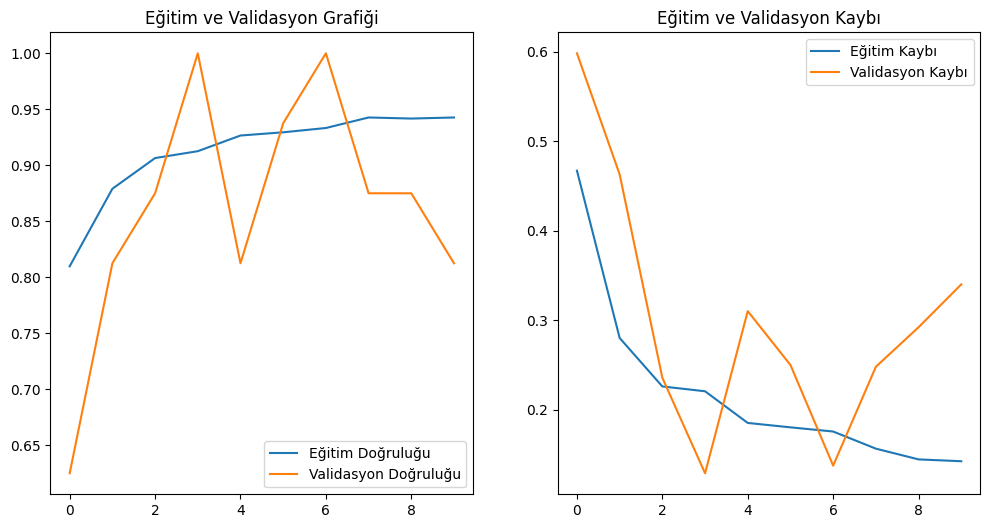


Model 'pneumonia_detector.h5' adıyla başarıyla kaydedildi.
Bu dosyayı artık tekli tahminler için de kullanabilirsiniz.


In [8]:
acc = history.history['accuracy']#history-->model.fit komutundan gelen değişkendir.keras listeleri accuracy de saklıyor bu yüzden accuracy seçiyoruz.
val_acc = history.history['val_accuracy']#deneme başarı notları için kullanıyoruz.
loss = history.history['loss']#ders içi hata puanlarını veriyor.
val_loss = history.history['val_loss']#deneme sınavı hata puanlarını veriyor.

epochs_range = range(len(acc))#grafiğin yatay eksenine epochsları koyuyoruz yatay eksende 1 den 10 a kadar olan sayılar olacak.

plt.figure(figsize=(12, 6))#tuval oluşturuyoruz.
plt.subplot(1, 2, 1)#oluşturacağım tuval 1 satırdan 2 sütundan ve ilk çizimimi soldaki birinci kutucağı yapacağım.
plt.plot(epochs_range, acc, label='Eğitim Doğruluğu')#plot çiz komutudur yatay eksen için epocs_range listesini kullanıyoruz dikey eksen için ise accuracy listesindeki ders içi başarı notlarını kullanıyoruz ve bu ikisini kullanarak bir çizgi çiz deniyor label ise bu çizginin efsanesi yani lagend'i bu çizgi eğitim doğruluğunu temsi ediyor gibi etiket yapıştırır.
plt.plot(epochs_range, val_acc, label='Validasyon Doğruluğu')#aynı grafiğin üzerine ikinci çizgimizi çizdiriyoruz bu çizgi validasyon notlarını gösterecek.
plt.legend(loc='lower right')#labellerin grafiğin sağ alt köşesine bir kutucuk içinde görünmesini sağlıyor
plt.title('Eğitim ve Validasyon Grafiği')#grafiğin ne olduğunu anlamamızı sağlıyor.

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Validasyon Kaybı')
plt.legend(loc='upper right')
plt.title('Eğitim ve Validasyon Kaybı')

plt.show()#grafiklerimizi göstermeye yarayan komut.

model.save('pneumonia_detector.h5')
print("\nModel 'pneumonia_detector.h5' adıyla başarıyla kaydedildi.")
print("Bu dosyayı artık tekli tahminler için de kullanabilirsiniz.")

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)#monitor='val_loss neyi izleyeceksin sorusuna cevap veriyor. || patience=3 sabır seviyesini belirliyor. || restore_best_weights=True değeri true olarak ayarlandığı zaman eğitim durduğu zaman modelin son anda ki ağırlıkları modele geri yüklüyor.

In [10]:
history = model.fit(
    train_generator,
    epochs = 50,
    validation_data = validation_generator,
    callbacks = [early_stopping]
)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

Dense(512,activation='relu'),
Dropout(0.5),
Dense(1,activation='sigmoid')

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.9482 - loss: 0.1479 - val_accuracy: 0.8750 - val_loss: 0.2980
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.9467 - loss: 0.1413 - val_accuracy: 0.8750 - val_loss: 0.2818
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 635ms/step - accuracy: 0.9498 - loss: 0.1333 - val_accuracy: 0.8750 - val_loss: 0.2896
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 654ms/step - accuracy: 0.9553 - loss: 0.1203 - val_accuracy: 0.8750 - val_loss: 0.2434
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.9569 - loss: 0.1174 - val_accuracy: 0.8750 - val_loss: 0.2700
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.9530 - loss: 0.1224 - val_accuracy: 0.9375 - val_loss: 0.1965
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 638ms/step - accuracy: 0.9584 - loss: 0.1147 - val_accuracy: 0.8750 - val_loss: 0.2154
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 628ms/step - accuracy: 0.9576 -

<Dense name=dense_3, built=False>

In [11]:
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)#test_loss, test_accuracy = model.evaluate() bu kısım modeli değerlendir anlamına gelir toplam hata puanı test_loss, genel başarı notu tes_accuracy değerlerini döndürüyor steps=test_generator.samples // batch_size bu kısm sınav kaç adımda biter sorusunu cevaplıyor.
print(f"Test Seti Doğruluğu: {test_accuracy* 100:.2f}")#aldığımız doğruluk notunu 100 ile çarpıyor .2f kısmı ise sayının virgülden sonra iki basamağını gösterir.
print(f"Test Seti Kaybı: {test_loss:.4f}%")#burada da test seti kaybını veriyor .4f bu kısım ise virgülden sonra dört basamağı gösterir.

19/19 ━━━━━━━━━━━━━━━━━━━━ 447s 25s/step - accuracy: 0.8849 - loss: 0.3128
Test Seti Doğruluğu: 88.49
Test Seti Kaybı: 0.3128%


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step


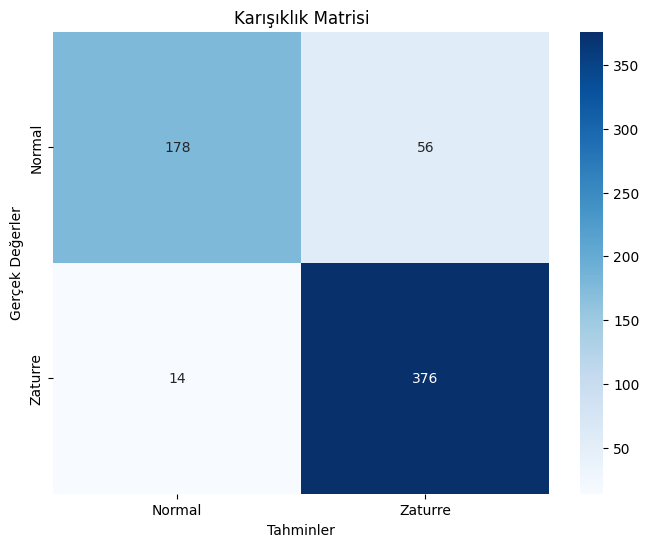


Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       0.93      0.76      0.84       234
     Zaturre       0.87      0.96      0.91       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.88       624
weighted avg       0.89      0.89      0.89       624



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

predictions = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)#bu komut model.predict komutudur modelin sınavdaki her bir soruya verdiği cevabı tek tek bize bir liste halinde veriyor son bir kaç resim dışarda kalmasın diye +1 ekleniyor.
predicted_classes = (predictions > 0.5).astype(int).flatten()# modelin cevap kağıdındaki sayılar 0 ile 1 arasındaki olasılıklardan oluşuyor  bu satır ise bu olasılıkları net bir cevaba dönüştürüyor 1 ise pneumonia 0 ise normal astype(int)bu komut ise bu kuraldan çıkan true false değerlerini 1-0 sayılarına çeviriyor flatten() ise sonucun tek boyutlu düz bir liste olmasını garantiliyor.
true_classes = test_generator.classes#sınavın resmi cevap anahtarıdır test_generator bu bilgiyi biliyor classes komutu ile bu bilgiyi alıyoruz
cm = confusion_matrix(true_classes, predicted_classes)#karışıklık matrisi aracımızı kullandığımız yer true_classes ve predicted_classes bu ikisini karşılaştırır ve bir özet tablosu çıkarır.
plt.figure(figsize=(8, 6))#bu özet tabloyu çizeceğimiz 8,6 boyutunda yeni bir tuval oluşturuyor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Zaturre'], yticklabels=['Normal', 'Zaturre'])#seaborn un ısı haritasıdır çizme komutudur matrisimizi renklendirerek gösteriyor cm bu tablodaki veriyi kullanır anlamına geliyor annot= true ise sayıları kutuların içine yazıyor fmt='d' bu değer ise sayıları tam sayı formatında yaz cmap='Blues' burda da renk paletini seçiyor mavi olarak seçiyor sonrasında da 0-1 yerine normal ve zaturre olarak seçiyoruz.
plt.xlabel('Tahminler')
plt.ylabel('Gerçek Değerler')
plt.title('Karışıklık Matrisi')
plt.show()
print("\nSınıflandırma Raporu:")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Zaturre']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


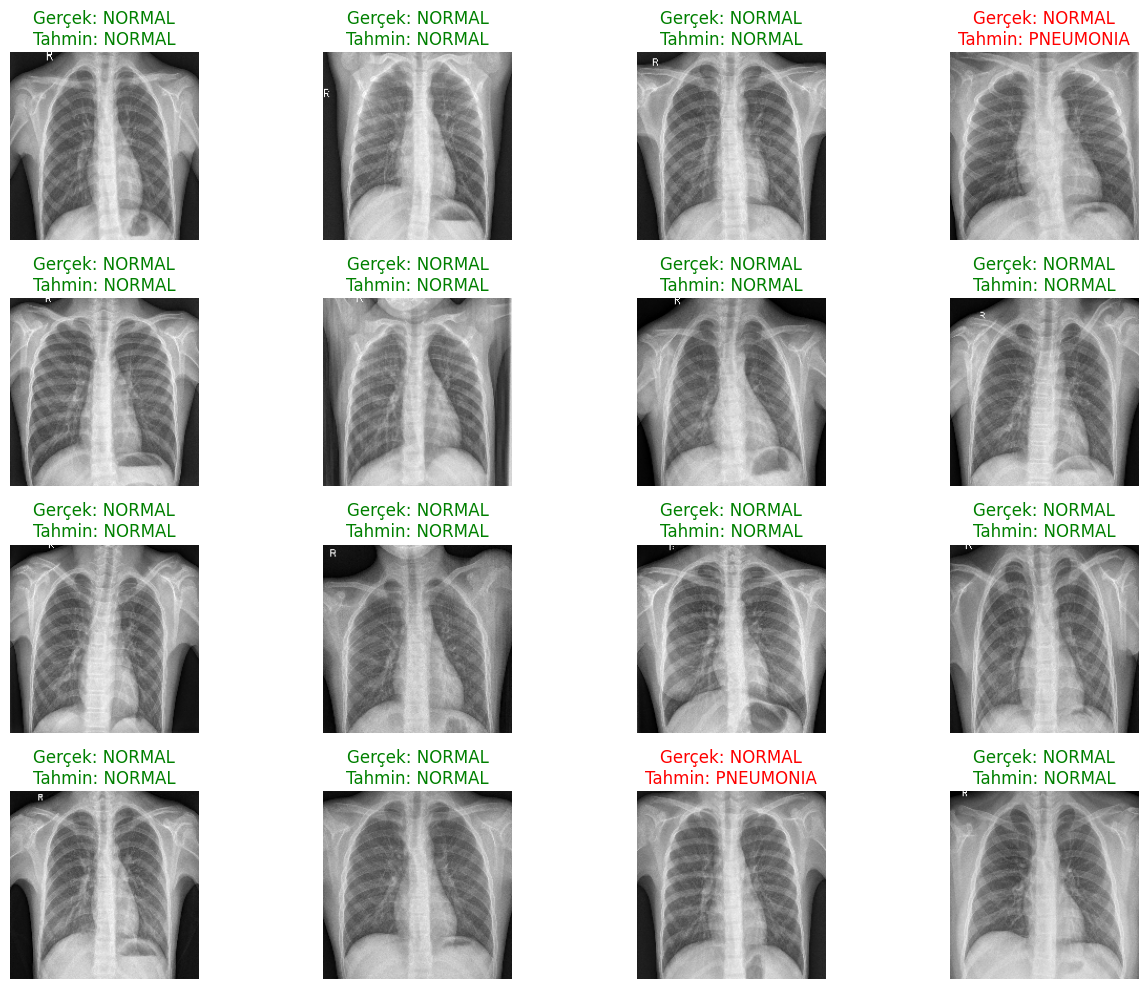

In [13]:
class_labels = {v: k for k, v in train_generator.class_indices.items()}#0 normal 1 pneumonia şeklinde tesine çevirerek bize tercümanlığı yapacak bir değişken oluşturur.
images, labels = next(test_generator)#test_generator dan rastgele bir soru alacağız 0 ve 1 den olyuşan bir listeyi veiyor.
predictions = model.predict(images)#resimler için bir tahmin yapıp 0 ile 1 arasında ki olasılık değerlerini listeye kaydediyor.
plt.figure(figsize=(15, 10))
for i in range(16):
  plt.subplot(4, 4, i + 1)#4 satır ve 4 sütundan oluşan 16 lık bir ızgaraya bölüyoruz.
  plt.imshow(images[i])#o anki kutucuğun listesine images listesindeki  i'nci resmi çizdiriyoruz.
  true_label = class_labels[labels[i]]#resmin gerçek etiketini bulmaya çalışıyor ve o resmin etiketini sayı olarak verecek biz de bu sayıyı class_labels a vererek metin karşılığını normal ve pneumonia olarak bulmuş olacağız.
  predicted_label = class_labels[(predictions[i] > 0.5).astype(int)[0]]#predictions[i] resim için bir olasılık verir bu olasılık %50 den büyük ise true false şeklinde döndermek istiyoruz astype(int) bu kısım ile 1 ve 0  çeviriyoruz.
  color = 'green' if true_label == predicted_label else 'red'#doğru tahmin ise yeşil yanlış tahmin ise kırmızı olacak.
  plt.title(f"Gerçek: {true_label}\nTahmin: {predicted_label}", color=color)
  plt.axis('off')#resmin etrafındaki gereksiz eksen çizgilerini x ve y kordinatlarını kapatarak temiz bir görüntü elde etmeye çalışıyoruz.
  plt.tight_layout()#döngü bittikten sonra çalışır 16 resmin başlıklarını ve resmin birbirine girmesini engelleyerek aralarındaki boşlukları otomatik olarak ayarlıyor.
plt.show()#16 resim bize ekranda gösteriyor.